# LSTM Training

In [5]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Reshape, Concatenate
from tensorflow.keras.optimizers import Adam
import sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..', '..')))
from src.captioning.common.preprocessing import Tokenizer
from src.captioning.lstm.model import LSTMCaptioner

In [6]:
data_dir = "../../../data/flickr8k"
features = np.load(os.path.join(data_dir, "features.npy"))
with open(os.path.join(data_dir, "features_index.json"), 'r') as f:
    features_index = json.load(f)
tokenizer = Tokenizer.load(os.path.join(data_dir, "tokenizer.json"))
with open(os.path.join(data_dir, "splits.json"), 'r') as f:
    splits = json.load(f)

def load_captions(file_path, tokenizer):
    with open(file_path, 'r') as f: lines = f.readlines()[1:]
    mapping = {}
    for line in lines:
        parts = line.split(',', 1)
        if len(parts) < 2: continue
        img_id, cap = parts[0], parts[1].strip()
        if img_id not in mapping: mapping[img_id] = []
        mapping[img_id].append(tokenizer.clean_caption(cap))
    return mapping
captions_mapping = load_captions(os.path.join(data_dir, "captions.txt"), tokenizer)

In [7]:
def data_generator(image_ids, mapping, features, features_index, tokenizer, batch_size=32):
    X1, X2, y = [], [], []
    pad_val = tokenizer.word_index[tokenizer.pad_token]
    for img_id in image_ids:
        if img_id not in mapping or img_id not in features_index: continue
        img_feature = features[features_index[img_id]]
        for caption in mapping[img_id]:
            seq = [tokenizer.word_index[word] for word in caption.split() if word in tokenizer.word_index]
            seq_padded = np.pad(seq, (0, max(0, tokenizer.max_length - len(seq))), 'constant', constant_values=pad_val)[:tokenizer.max_length]
            y_seq = np.append(seq_padded, pad_val)
            X1.append(img_feature)
            X2.append(seq_padded)
            y.append(y_seq)
            if len(X1) == batch_size:
                yield (np.array(X1), np.array(X2)), np.array(y)
                X1, X2, y = [], [], []

In [8]:
def define_keras_model(vocab_size, max_length, embed_dim, hidden_dim, num_layers=1):
    inputs1 = Input(shape=(2048,))
    fe1 = Dense(embed_dim, activation='relu', name='image_projection')(inputs1)
    fe1_reshaped = Reshape((1, embed_dim))(fe1)
    
    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding')(inputs2)
    
    sequence_input = Concatenate(axis=1)([fe1_reshaped, se1])
    
    x = sequence_input
    for i in range(num_layers):
        x = LSTM(hidden_dim, return_sequences=True, name=f'lstm_{i}')(x)
        
    outputs = Dense(vocab_size, activation='softmax', name='dense_output')(x)
    
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001))
    return model

In [9]:
configs = [
    {"name": "lstm_1layer_128", "layers": 1, "hidden_dim": 128, "embed_dim": 256},
    {"name": "lstm_1layer_512", "layers": 1, "hidden_dim": 512, "embed_dim": 256},
    {"name": "lstm_2layer_128", "layers": 2, "hidden_dim": 128, "embed_dim": 256},
    {"name": "lstm_2layer_512", "layers": 2, "hidden_dim": 512, "embed_dim": 256},
    {"name": "lstm_3layer_128", "layers": 3, "hidden_dim": 128, "embed_dim": 256},
    {"name": "lstm_3layer_512", "layers": 3, "hidden_dim": 512, "embed_dim": 256},
]

epochs = 5
batch_size = 64
total_samples = sum(len(captions_mapping.get(i, [])) for i in splits['train'])
steps = total_samples // batch_size
print(f"Total training captions: {total_samples}, Steps per epoch: {steps}")

Total training captions: 30000, Steps per epoch: 468


In [10]:
weights_dir = "../../../weights/captioning/lstm"
os.makedirs(weights_dir, exist_ok=True)
histories = {}

for config in configs:
    print(f"\n--- Training Variation: {config['name']} ---")
    model = define_keras_model(
        tokenizer.vocab_size, tokenizer.max_length, 
        config['embed_dim'], config['hidden_dim'], config['layers']
    )
    
    history = []
    for e in range(epochs):
        gen = data_generator(splits['train'], captions_mapping, features, features_index, tokenizer, batch_size)
        h = model.fit(gen, epochs=1, steps_per_epoch=steps, verbose=1)
        history.append(h.history['loss'][0])
        
    histories[config['name']] = history
    model.save_weights(os.path.join(weights_dir, f"{config['name']}.weights.h5"))


--- Training Variation: lstm_1layer_128 ---
468/468 ━━━━━━━━━━━━━━━━━━━━ 252s 518ms/step - loss: 4.5928
468/468 ━━━━━━━━━━━━━━━━━━━━ 225s 481ms/step - loss: 3.5796
468/468 ━━━━━━━━━━━━━━━━━━━━ 176s 376ms/step - loss: 3.2956
468/468 ━━━━━━━━━━━━━━━━━━━━ 179s 382ms/step - loss: 3.1176
468/468 ━━━━━━━━━━━━━━━━━━━━ 185s 394ms/step - loss: 2.9817

--- Training Variation: lstm_1layer_512 ---
468/468 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - loss: 3.9512
468/468 ━━━━━━━━━━━━━━━━━━━━ 535s 1s/step - loss: 3.1572
468/468 ━━━━━━━━━━━━━━━━━━━━ 589s 1s/step - loss: 2.9094
468/468 ━━━━━━━━━━━━━━━━━━━━ 579s 1s/step - loss: 2.7330
468/468 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - loss: 2.5952

--- Training Variation: lstm_2layer_128 ---
468/468 ━━━━━━━━━━━━━━━━━━━━ 229s 460ms/step - loss: 5.0916
468/468 ━━━━━━━━━━━━━━━━━━━━ 223s 477ms/step - loss: 4.2819
468/468 ━━━━━━━━━━━━━━━━━━━━ 222s 474ms/step - loss: 3.8083
468/468 ━━━━━━━━━━━━━━━━━━━━ 213s 455ms/step - loss: 3.5149
468/468 ━━━━━━━━━━━━━━━━━━━━ 207s 442ms/

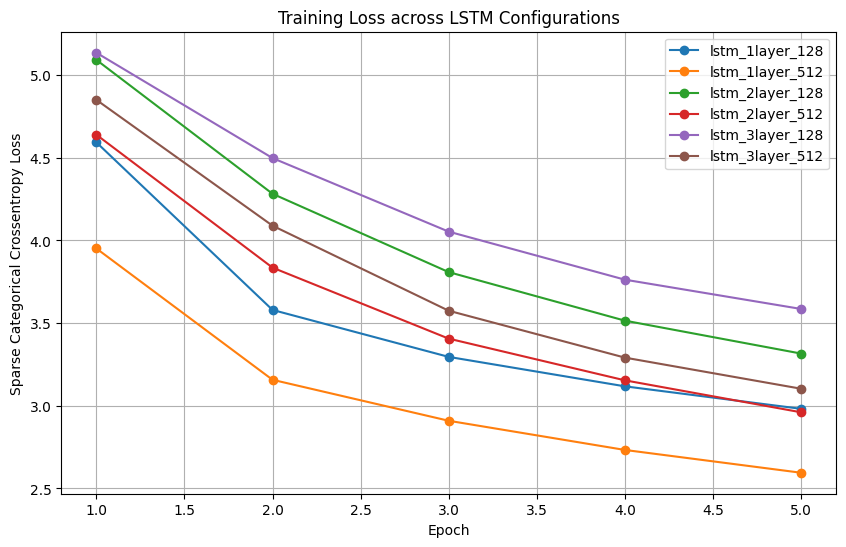

In [11]:
plt.figure(figsize=(10, 6))
for name, loss_hist in histories.items():
    plt.plot(range(1, epochs + 1), loss_hist, marker='o', label=name)
plt.title('Training Loss across LSTM Configurations')
plt.xlabel('Epoch')
plt.ylabel('Sparse Categorical Crossentropy Loss')
plt.legend()
plt.grid(True)
plt.show()